# Analysis of COVID-19 Data: Cases, Deaths, and Vaccinations

This notebook analyzes a dataset containing information on COVID-19 cases, deaths, and vaccinations across several countries.  The data covers a period from November 1st, 2024 to November 30th, 2024.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data = pd.read_csv('Dataset.csv')
Data.columns = Data.columns.str.strip().str.lower().str.replace(' ', '_')
Data['date'] = pd.to_datetime(Data['date'], errors='coerce')



Data.head()

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown


In [ ]:
Data.tail()

,date,country,new_cases,new_deaths,vaccinated
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown
164,2024-11-30,China,0.0,0.0,unknown


In [ ]:
Data.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        150 non-null    datetime64[ns]
 1   country     165 non-null    object        
 2   new_cases   154 non-null    float64       
 3   new_deaths  139 non-null    float64       
 4   vaccinated  165 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 6.6+ KB


In [ ]:


try:
    Data['date'] = pd.to_datetime(Data['date'], format='%m/%d/%Y', errors='coerce')
    print("Successfully parsed most dates using %m/%d/%Y format")
except:
    pass

error_rows = Data[Data['date'].isnull()]
if not error_rows.empty:
    error_rows.loc[:, 'date'] = pd.to_datetime(error_rows['date'], format='%d/%m/%Y', errors='coerce')
    Data.loc[Data['date'].isnull(),'date'] = error_rows['date']
    print("Successfully parsed remaining dates using %d/%m/%Y format")

Successfully parsed most dates using %m/%d/%Y format
Successfully parsed remaining dates using %d/%m/%Y format


In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        150 non-null    datetime64[ns]
 1   country     165 non-null    object        
 2   new_cases   154 non-null    float64       
 3   new_deaths  139 non-null    float64       
 4   vaccinated  165 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 6.6+ KB


## Data Cleaning and Preparation

The initial dataset contained missing values represented as "unknown" in the 'new_cases', 'new_deaths', and 'vaccinated' columns. Because this is time series data, a forward and backward fill method was employed to impute these missing values, leveraging the available data points before and after the gaps.  

The 'vaccinated' column was initially of float type; it was converted to numeric to ensure consistency and compatibility with the other numerical columns for calculations and plotting.
 * While this approach is suitable for time series data, more sophisticated imputation techniques (such as those using machine learning models or statistical methods) might be considered for a larger and more complex dataset to achieve more robust results.

In [ ]:
Data[Data.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
7,2024-11-02,Australia,0.0,NaN,336
12,2024-11-03,Australia,NaN,NaN,474
13,2024-11-03,Brazil,641.0,NaN,47
22,2024-11-05,Argentina,283.0,NaN,41
25,NaT,Canada,867.0,43.0,485
30,2024-11-06,Canada,152.0,NaN,421
35,NaT,Canada,560.0,28.0,449
40,2024-11-08,Brazil,212.0,NaN,313
53,NaT,Argentina,532.0,26.0,378


In [ ]:
Data['vaccinated'] = pd.to_numeric(Data['vaccinated'], errors='coerce')
Data.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        150 non-null    datetime64[ns]
 1   country     165 non-null    object        
 2   new_cases   154 non-null    float64       
 3   new_deaths  139 non-null    float64       
 4   vaccinated  148 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 6.6+ KB


In [ ]:
#splitting the Data into two distinct groups.
#for statistical description
cat_Data = Data.select_dtypes(include = ['object'])
num_Data = Data.select_dtypes(include = ['number'])

def discrete_uni_analysis(Data):
    for col_name in Data:
        print('\n','*'*5,col_name, '*'*5)
        print(Data[col_name].agg(['count', 'nunique', 'unique']))
        print('value_counts: \n', Data[col_name].value_counts())
discrete_uni_analysis(cat_Data)


def num_uni_analysis(Data):
    for col_name in Data:
        print('\n','*'*5,col_name, '*'*5)
        print(Data[col_name].agg(['count', 'min', 'max', 'mean', 'median', 'std']))

num_uni_analysis(num_Data)


 ***** country *****
count                                                165
nunique                                                5
unique     [Argentina, Australia, Brazil, Canada, China]
Name: country, dtype: object
value_counts: 
 country
Brazil       34
China        34
Argentina    33
Australia    33
Canada       31
Name: count, dtype: int64

 ***** new_cases *****
count      154.000000
min          0.000000
max       1730.000000
mean       579.032468
median     589.000000
std        406.078350
Name: new_cases, dtype: float64

 ***** new_deaths *****
count     139.000000
min         0.000000
max        86.000000
mean       28.474820
median     29.000000
std        20.640586
Name: new_deaths, dtype: float64

 ***** vaccinated *****
count     148.000000
min         2.000000
max       499.000000
mean      302.027027
median    346.500000
std       151.993956
Name: vaccinated, dtype: float64


In [ ]:
Data[['new_cases', 'new_deaths', 'vaccinated']].describe()

,new_cases,new_deaths,vaccinated
count,154.000000,139.000000,148.000000
mean,579.032468,28.474820,302.027027
std,406.078350,20.640586,151.993956
min,0.000000,0.000000,2.000000
25%,271.750000,13.500000,171.000000
50%,589.000000,29.000000,346.500000
75%,801.250000,39.500000,428.500000
max,1730.000000,86.000000,499.000000


In [ ]:
Data = Data.sort_values(['country', 'date'])

Data[['new_cases', 'new_deaths', 'vaccinated']] = (
    Data.groupby('country')[['new_cases', 'new_deaths', 'vaccinated']].ffill()
)

In [ ]:
Data[Data.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,NaN
53,NaT,Argentina,532.0,26.0,378.0
92,NaT,Argentina,532.0,26.0,378.0
110,NaT,Argentina,1248.0,62.0,378.0
87,NaT,Australia,942.0,47.0,474.0
122,NaT,Australia,1087.0,54.0,395.0
123,NaT,Australia,1087.0,54.0,395.0
143,NaT,Australia,1074.0,54.0,446.0
4,2024-11-01,Canada,176.0,8.0,NaN
25,NaT,Canada,867.0,43.0,485.0


In [ ]:
Data = Data.sort_values(['country', 'date'])

Data[['new_cases', 'new_deaths', 'vaccinated']] = (
    Data.groupby('country')[['new_cases', 'new_deaths', 'vaccinated']].bfill()
)

In [ ]:
Data[Data.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
53,NaT,Argentina,532.0,26.0,378.0
92,NaT,Argentina,532.0,26.0,378.0
110,NaT,Argentina,1248.0,62.0,378.0
87,NaT,Australia,942.0,47.0,474.0
122,NaT,Australia,1087.0,54.0,395.0
123,NaT,Australia,1087.0,54.0,395.0
143,NaT,Australia,1074.0,54.0,446.0
25,NaT,Canada,867.0,43.0,485.0
35,NaT,Canada,560.0,28.0,449.0
82,NaT,Canada,677.0,33.0,323.0


In [ ]:
 # Remove duplicates
Data = Data.drop_duplicates()

 # Check for remaining missing values
print(Data.isnull().sum())

date          12
country        0
new_cases      0
new_deaths     0
vaccinated     0
dtype: int64


In [ ]:
data1 = Data.dropna(subset = ['date'])

cat_data1 = Data.select_dtypes(include = ['object'])
num_data1 = Data.select_dtypes(include = ['number'])

data1.isnull().sum()

,0
date,0
country,0
new_cases,0
new_deaths,0
vaccinated,0


## Outlier Analysis and Justification

Box plots were used to visually inspect the data for outliers in 'NEW Cases', 'NEW_DEATHS', and 'vaccinated'. 'NEW Cases' showed no outliers.  A small number of outliers (one or two) were observed in 'NEW_DEATHS' and 'vaccinated'.  Given the small sample size of this dataset, removing these few outliers could potentially lead to a loss of valuable information. Also, extreme values in epidemiological data are sometimes legitimate and not errors.  Therefore, no outlier treatment was implemented.

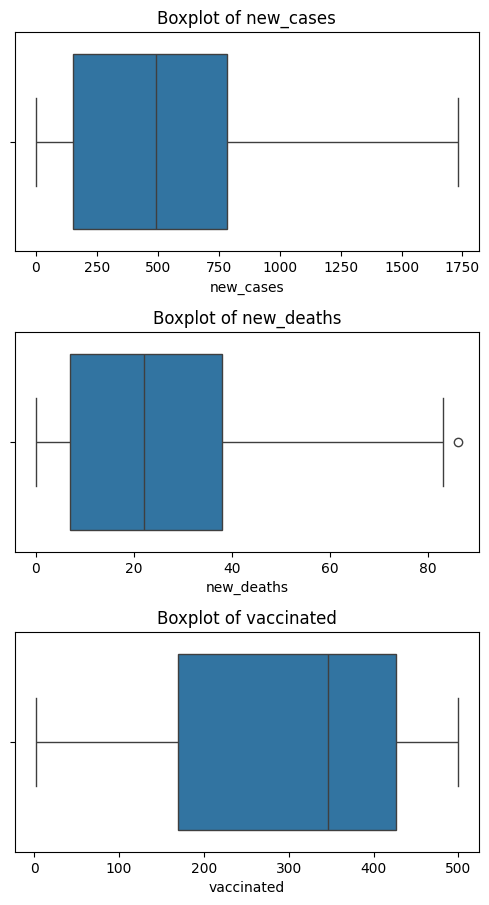

In [ ]:

plt.figure(figsize=(5, len(num_data1)*3))
for i, col in enumerate(num_data1,1):
    plt.subplot(len(num_data1), 1, i)
    sns.boxplot(x = data1[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

In [ ]:

#statiscal description for both numerical and categorical column

num_uni_analysis(data1[['new_cases', 'new_deaths', 'vaccinated']])
print( )
discrete_uni_analysis(data1[['country']])


data1[['new_cases', 'new_deaths', 'vaccinated']].describe()


 ***** new_cases *****
count      137.000000
min          0.000000
max       1730.000000
mean       539.759124
median     491.000000
std        422.548544
Name: new_cases, dtype: float64

 ***** new_deaths *****
count     137.000000
min         0.000000
max        86.000000
mean       26.072993
median     22.000000
std        21.104305
Name: new_deaths, dtype: float64

 ***** vaccinated *****
count     137.000000
min         2.000000
max       499.000000
mean      296.007299
median    346.000000
std       154.565639
Name: vaccinated, dtype: float64


 ***** country *****
count                                                137
nunique                                                5
unique     [Argentina, Australia, Brazil, Canada, China]
Name: country, dtype: object
value_counts: 
 country
Brazil       30
China        28
Argentina    27
Australia    27
Canada       25
Name: count, dtype: int64


,new_cases,new_deaths,vaccinated
count,137.000000,137.000000,137.000000
mean,539.759124,26.072993,296.007299
std,422.548544,21.104305,154.565639
min,0.000000,0.000000,2.000000
25%,152.000000,7.000000,169.000000
50%,491.000000,22.000000,346.000000
75%,785.000000,38.000000,427.000000
max,1730.000000,86.000000,499.000000


In [ ]:

#this shows how the new_cases, new_death and vaccinated for each country increased day by day


daily_summary = data1.groupby(['country', 'date']).sum().reset_index()
daily_summary

,country,date,new_cases,new_deaths,vaccinated
0,Argentina,2024-11-01,23.0,1.0,195.0
1,Argentina,2024-11-02,23.0,1.0,195.0
2,Argentina,2024-11-03,337.0,16.0,425.0
3,Argentina,2024-11-04,96.0,4.0,383.0
4,Argentina,2024-11-05,283.0,4.0,41.0
...,...,...,...,...,...
132,China,2024-11-26,949.0,47.0,444.0
133,China,2024-11-27,521.0,26.0,17.0
134,China,2024-11-28,401.0,20.0,190.0
135,China,2024-11-29,67.0,3.0,490.0


* This show the date each country as an highest value of new_cases, new_deaths and vaccinated value

In [ ]:
peak_cases = daily_summary.loc[daily_summary.groupby('country')['new_cases'].idxmax()]

print("Peak daily cases and peak_deaths:\n", peak_cases)

Peak daily cases and peak_deaths:
        country       date  new_cases  new_deaths  vaccinated
25   Argentina 2024-11-29     1661.0        83.0       220.0
51   Australia 2024-11-28     1730.0        86.0       347.0
54      Brazil 2024-11-01      971.0        48.0       430.0
108     Canada 2024-11-30     1133.0        56.0       438.0
131      China 2024-11-25     1093.0        54.0       266.0


### Analysis of Cumulative Trends

The data reveals distinct cumulative infection patterns across the analyzed countries.  Australia showed a relatively steady increase in cumulative cases, with The cumulative number of cases increased steadily, reaching 9,480 by 2024-11-21 and 19,034 by 2024-11-30.  In contrast, Brazil experienced a sharper initial rise followed by a decrease.   Potential contributing factors include variations in vaccination rates, population density, and the implementation of public health measures.  Further investigation is needed to fully understand these differences.

In [ ]:


data2 = data1.sort_values(['country', 'date'])
data2[['cum_cases','cum_deaths', 'cum_vaccinated']] = data1.groupby('country')[['new_cases','new_deaths', 'vaccinated']].cumsum()

data2.head( )

,date,country,new_cases,new_deaths,vaccinated,cum_cases,cum_deaths,cum_vaccinated
0,2024-11-01,Argentina,23.0,1.0,195.0,23.0,1.0,195.0
6,2024-11-02,Argentina,23.0,1.0,195.0,46.0,2.0,390.0
11,2024-11-03,Argentina,337.0,16.0,425.0,383.0,18.0,815.0
16,2024-11-04,Argentina,96.0,4.0,383.0,479.0,22.0,1198.0
22,2024-11-05,Argentina,283.0,4.0,41.0,762.0,26.0,1239.0


In [ ]:
latest_cumulative = data2.groupby('country').tail(1)[['country', 'cum_cases', 'cum_deaths','vaccinated']]
print(latest_cumulative)

       country  cum_cases  cum_deaths  vaccinated
158  Argentina    19665.0       944.0       220.0
159  Australia    19034.0       901.0       428.0
160     Brazil    12438.0       603.0        62.0
161     Canada    10425.0       517.0       438.0
163      China    12385.0       607.0       490.0


In [ ]:
australia_data = data2[data2['country'] == 'Australia']
print(australia_data.tail())

          date    country  new_cases  new_deaths  vaccinated  cum_cases  \
133 2024-11-25  Australia     1196.0        59.0       353.0    12613.0   
138 2024-11-26  Australia     1568.0        78.0       496.0    14181.0   
148 2024-11-28  Australia     1730.0        86.0       347.0    15911.0   
154 2024-11-29  Australia     1650.0        82.0       491.0    17561.0   
159 2024-11-30  Australia     1473.0        73.0       428.0    19034.0   

     cum_deaths  cum_vaccinated  
133       582.0          9229.0  
138       660.0          9725.0  
148       746.0         10072.0  
154       828.0         10563.0  
159       901.0         10991.0  


In [ ]:
country_totals = data2.groupby('country')[['new_cases', 'new_deaths', 'vaccinated']].sum().reset_index()
print(country_totals.sort_values('new_cases', ascending=False))

     country  new_cases  new_deaths  vaccinated
0  Argentina    19665.0       944.0      5594.0
1  Australia    19034.0       901.0     10991.0
2     Brazil    12438.0       603.0      6350.0
4      China    12385.0       607.0      7535.0
3     Canada    10425.0       517.0     10083.0


In [ ]:
country_totals['fatality_rate'] = (country_totals['new_deaths'] / country_totals['new_cases'])*100
print(country_totals[['country', 'new_cases', 'new_deaths', 'fatality_rate']])

     country  new_cases  new_deaths  fatality_rate
0  Argentina    19665.0       944.0       4.800407
1  Australia    19034.0       901.0       4.733635
2     Brazil    12438.0       603.0       4.848046
3     Canada    10425.0       517.0       4.959233
4      China    12385.0       607.0       4.901090


In [ ]:
print('\nTop 5 countries by total cases:\n', country_totals.nlargest(2, 'new_cases'))
print('\nTop 5 countries by total deaths:\n', country_totals.nlargest(2, 'new_deaths'))
print('\nLowest 5 countries by fatality rate:\n', country_totals.nsmallest(2, 'fatality_rate'))


Top 5 countries by total cases:
      country  new_cases  new_deaths  vaccinated  fatality_rate
0  Argentina    19665.0       944.0      5594.0       4.800407
1  Australia    19034.0       901.0     10991.0       4.733635

Top 5 countries by total deaths:
      country  new_cases  new_deaths  vaccinated  fatality_rate
0  Argentina    19665.0       944.0      5594.0       4.800407
1  Australia    19034.0       901.0     10991.0       4.733635

Lowest 5 countries by fatality rate:
      country  new_cases  new_deaths  vaccinated  fatality_rate
1  Australia    19034.0       901.0     10991.0       4.733635
0  Argentina    19665.0       944.0      5594.0       4.800407


This section generates a series of line plots, with one plot dedicated to each individual country present in the dataset. This allows for a granular examination of the COVID-19 pandemic's progression within specific geographical regions.


**Purpose:** This visualization helps in:
* Identifying the peaks and troughs of the pandemic within individual nations.
* Observing the impact of interventions or vaccination efforts on new cases and deaths in specific countries.
* Comparing the timeline and severity of the pandemic's waves across different regions.

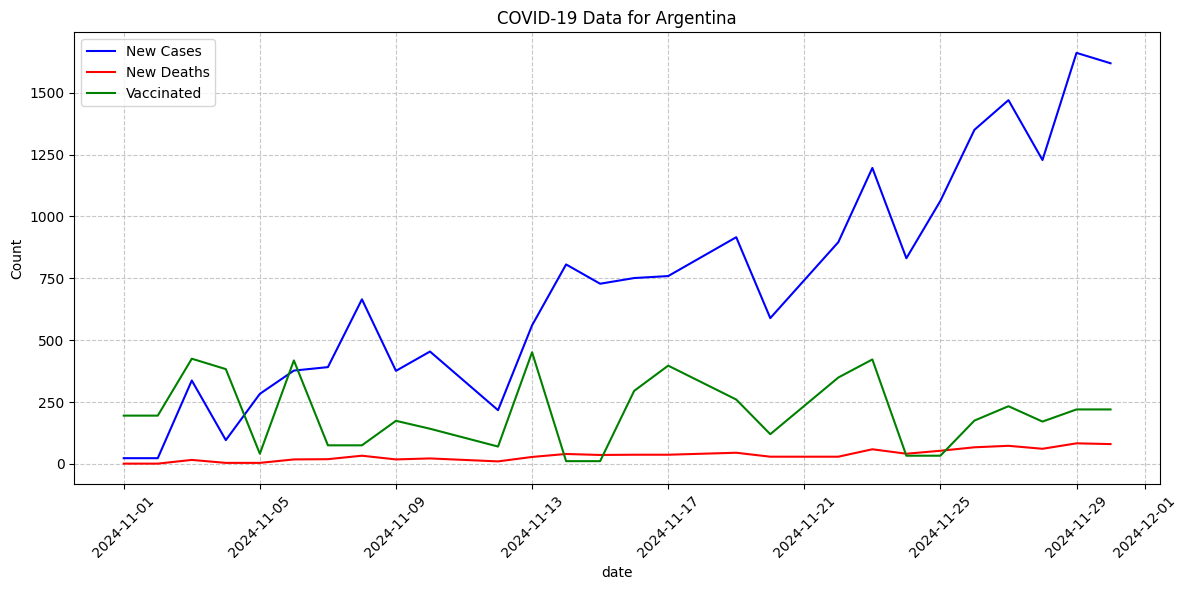

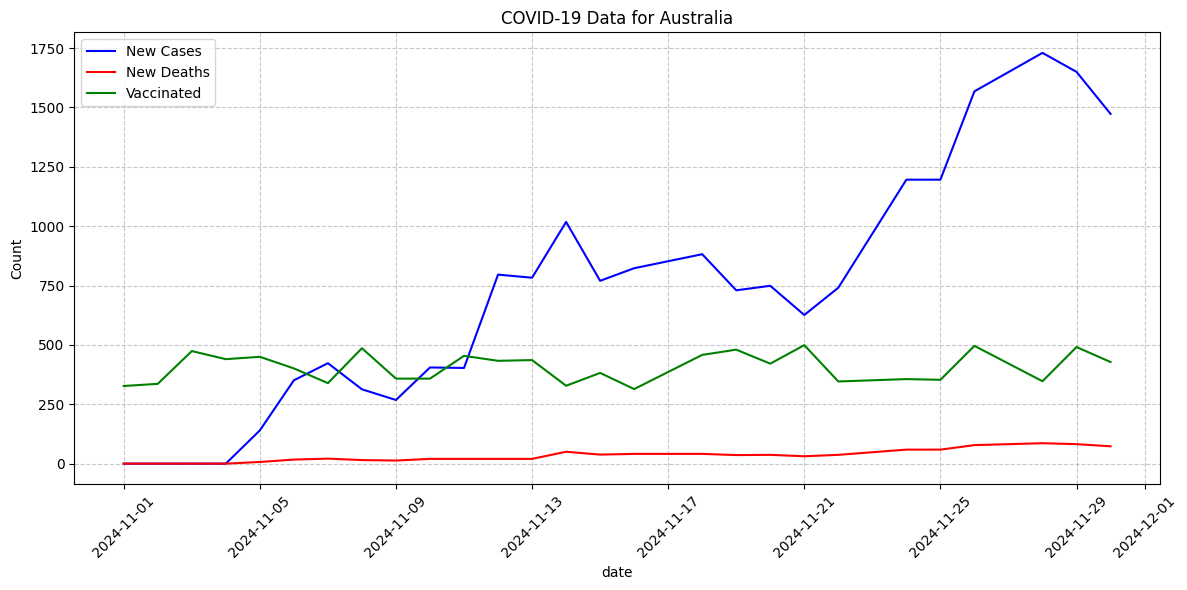

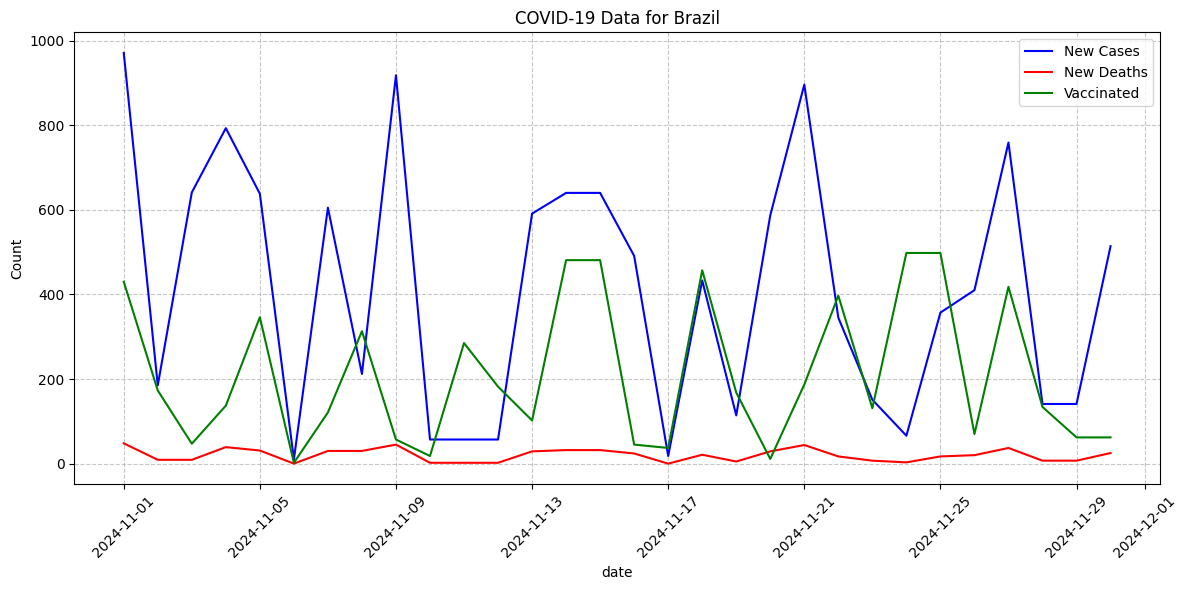

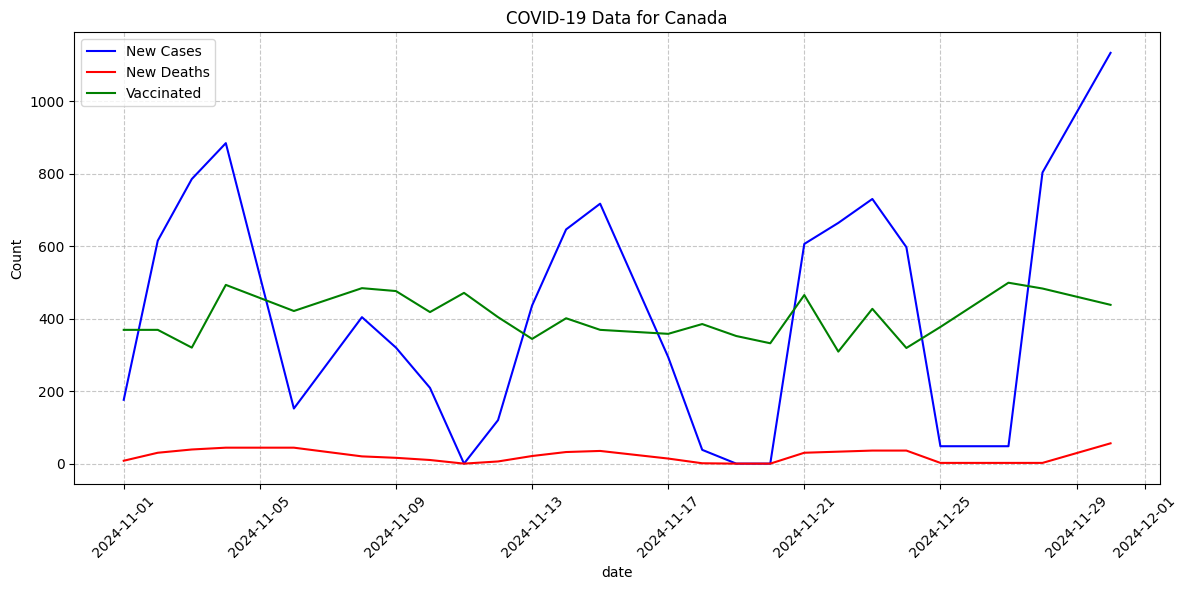

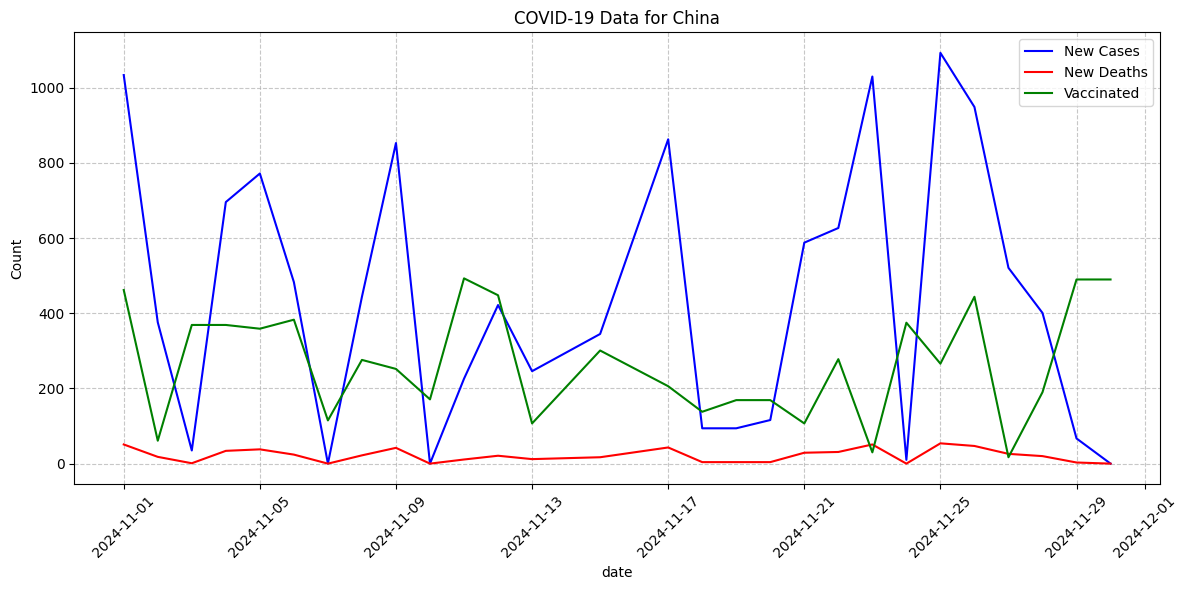

In [ ]:


# Get unique list of countries
unique_countries = data1['country'].unique()

for country_name in unique_countries:
    country_df = data1[data1['country'] == country_name].copy() # Filter data for the current country

    plt.figure(figsize=(12, 6))
    plt.plot(country_df['date'], country_df['new_cases'], label='New Cases', color='blue')
    plt.plot(country_df['date'], country_df['new_deaths'], label='New Deaths', color='red')
    plt.plot(country_df['date'], country_df['vaccinated'], label='Vaccinated', color='green') # Adjust if 'vaccinated' is cumulative vs daily new
    plt.xlabel('date')
    plt.ylabel('Count')
    plt.title(f'COVID-19 Data for {country_name}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7) # Add grid for better readability
    plt.tight_layout()
    plt.show()

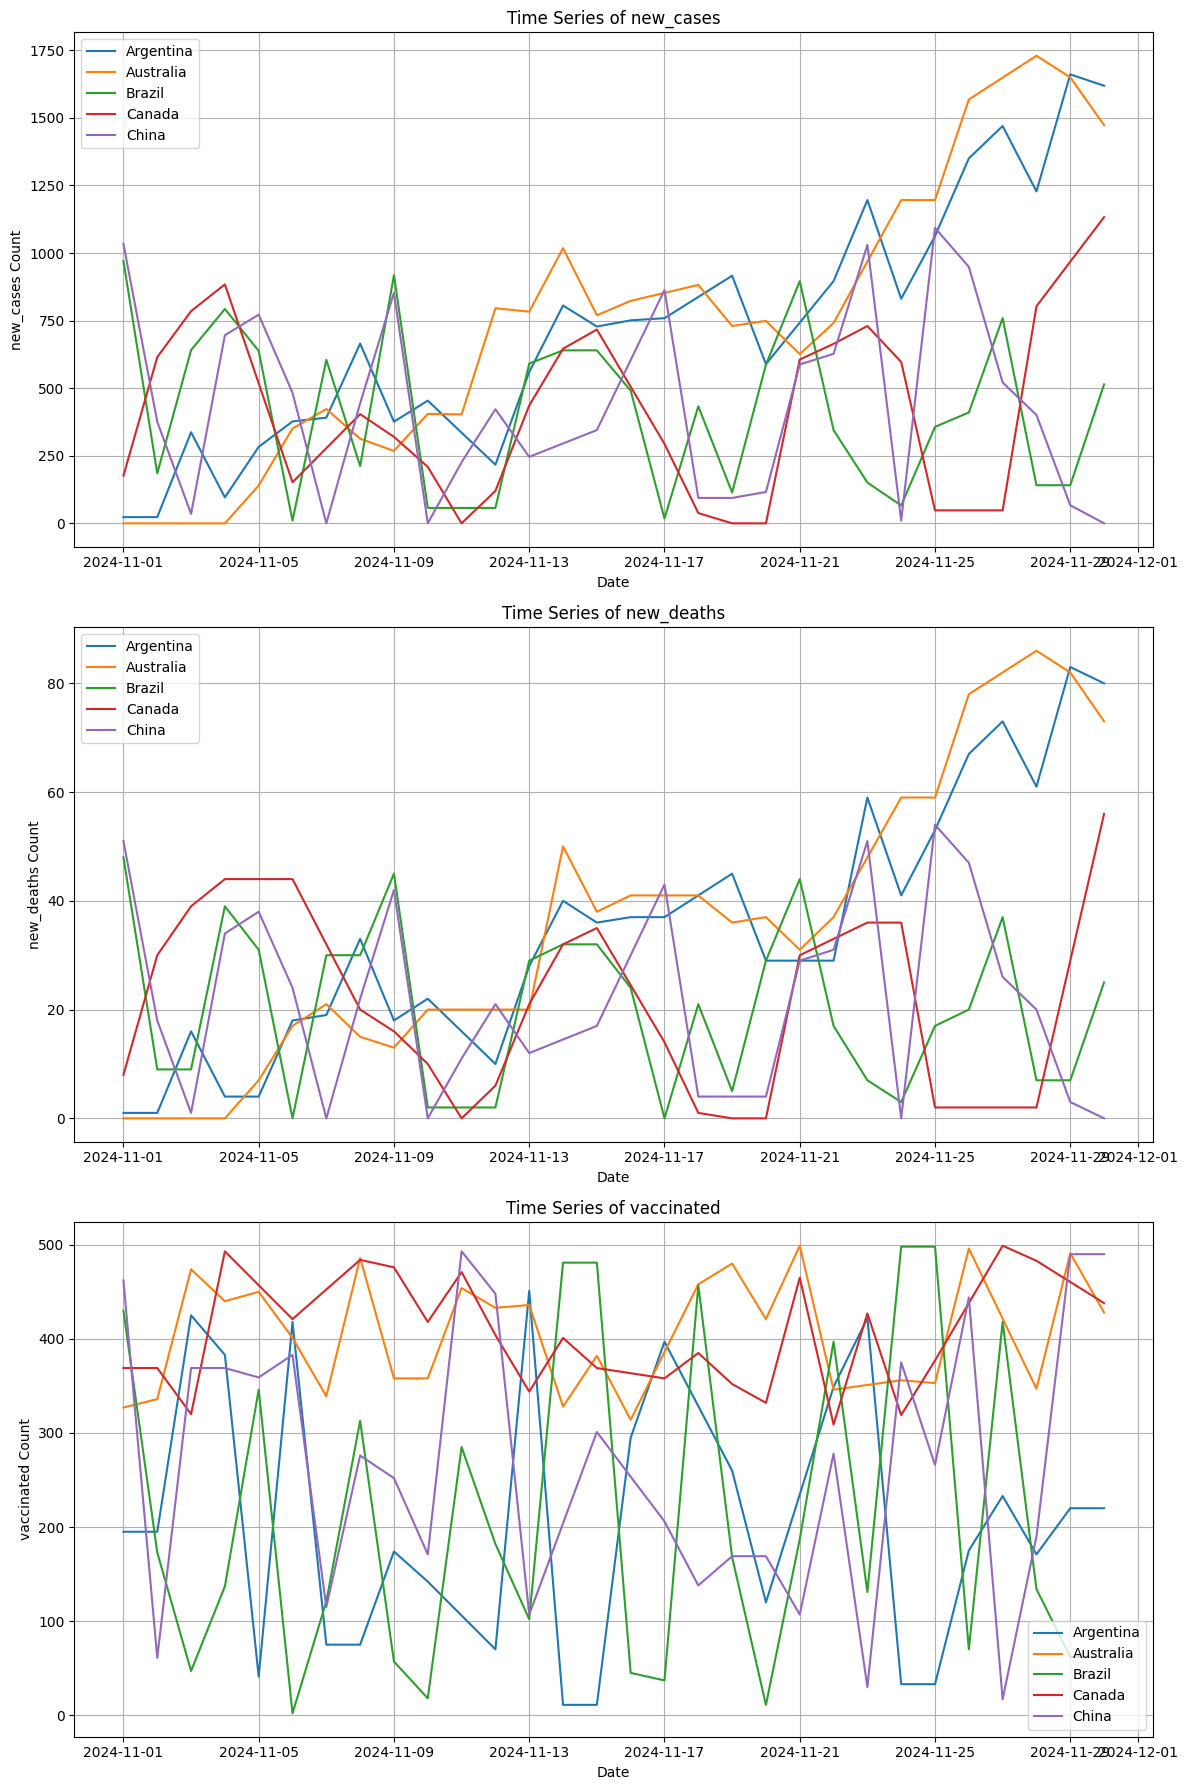

In [ ]:
data1 = data1.sort_values(by=['country', 'date'])


# Plotting
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

for i, col in enumerate(['new_cases', 'new_deaths', 'vaccinated']):
    for country in data1['country'].unique():
        country_data = data1[data1['country'] == country]
        axes[i].plot(country_data['date'], country_data[col], label=country)
    axes[i].set_title(f'Time Series of {col}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(f'{col} Count')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Country-Specific Insights (based on the visible portions of the graphs):
 * Argentina: The graph shows multiple significant peaks in new cases. The vaccination rollout appears to begin after the initial waves, and it would be interesting to see if subsequent waves are less severe or if the death rate decreases after widespread vaccination.
 * Australia: Australia's "New Cases" show a relatively flatter trend initially, with a noticeable rise later in the timeline. This could suggest stricter initial containment measures or a later impact of the virus. Vaccination appears to ramp up, and observing its correlation with the later case trends would be crucial.
 * Brazil: Brazil's graph indicates consistently high and fluctuating "New Cases" and "New Deaths" throughout the visible period. The vaccination line shows a steady increase, but the impact on case and death numbers seems less immediate or pronounced compared to some other countries, potentially due to variations in public health measures, vaccine efficacy against circulating variants, or data reporting.
 * Canada: Canada's "New Cases" exhibit clear waves. The vaccination program seems to start and accelerate during or after early waves. A key insight would be to observe if the intensity of subsequent case waves or the associated death rates diminish as vaccination rates increase.
 * China: China's graph is particularly interesting due to its early and distinct initial peak in "New Cases," followed by a period of very low reported cases for a significant duration, then another rise. The "Vaccinated" line shows a substantial increase. This pattern might reflect their stringent "zero-COVID" policies and later changes in strategy or the emergence of new variants.

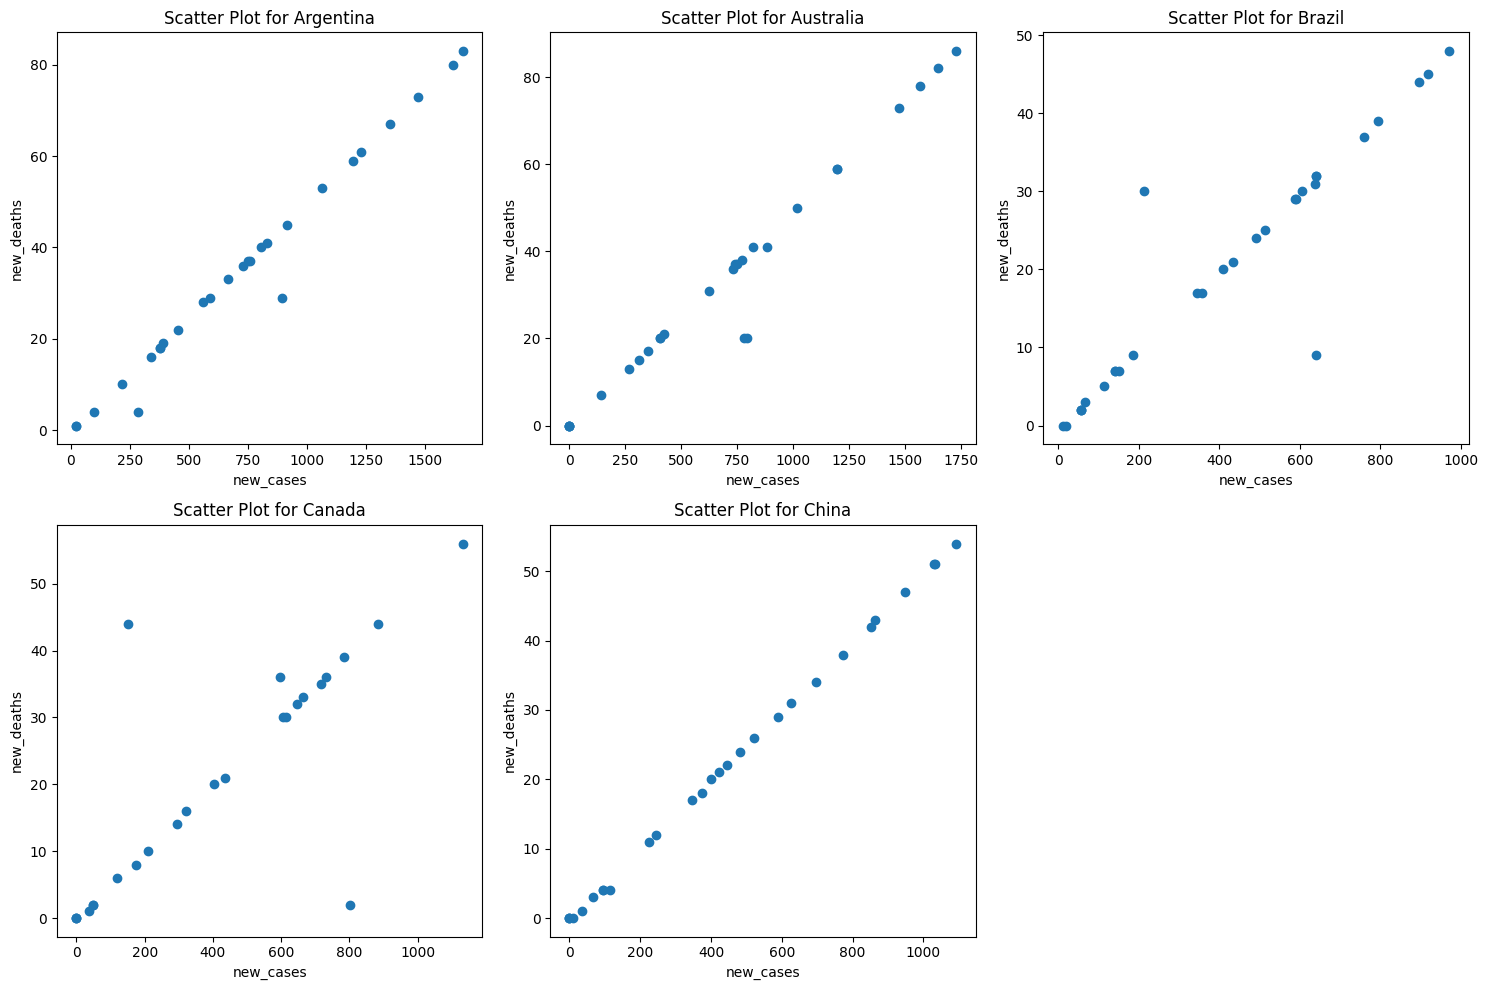

In [ ]:


# Determine the number of rows and columns for subplots
num_countries = len(country_data)
num_rows = 2
num_cols = 3  # Adjust this based on the number of countries
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten axes array for easy iteration
axes = axes.flatten()

country_data = {}
for country in data1['country'].unique():
    country_df = data1[data1['country'] == country]
    country_data[country] = {
        'new_deaths': country_df['new_deaths'].tolist(),
        'new_cases': country_df['new_cases'].tolist(),
        'vaccinated': country_df['vaccinated']
    }

# Iterate through countries and create subplots
for i, (country, data) in enumerate(country_data.items()):
    ax = axes[i]
    ax.scatter(data["new_cases"], data["new_deaths"])
    ax.set_xlabel("new_cases")
    ax.set_ylabel("new_deaths")
    ax.set_title(f"Scatter Plot for {country}")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

A profound and consistent insight derived from these graphs is the strong correlation between the 'New Cases' (blue line) and 'New Deaths' (red line) across all analyzed countries. Peaks in new infections are invariably followed by corresponding peaks in new fatalities, albeit with a noticeable time lag. This lag underscores the natural progression of COVID-19 from infection to severe illness and, in unfortunate cases, death. This predictable relationship highlights the direct human cost of viral transmission and emphasizes the critical importance of early public health interventions.